In [1]:
import os
import sys
from pathlib import Path

# Ensure project root is on path
notebook_dir = Path().absolute()
if notebook_dir.name == 'examples':
    os.chdir(notebook_dir.parent)

from src.metrics import fisher_batch_average

import torch
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])

## Configuration
Set paths to your data and checkpoints here.

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
DATASET_TYPE   = "ts_young"          # "ts_young" or "lsd"
DATA_PATH      = "data/ts_young/ts_young_TR0.72.mat"  # used when DATASET_TYPE=="ts_young"
LSD_DATA_DIR   = "data/lsd"          # used when DATASET_TYPE=="lsd"
CHECKPOINT_DIR = "checkpoints"
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
N_TIMEPOINTS   = 200                 # simulation length for figures
N_PATHS        = 10                  # number of initial conditions to simulate
BATCH_SIZE     = 4                  # batch size for computing Fisher scores

print(f"Device: {DEVICE}")

Device: cpu


## 1. Load Dataset

In [3]:
from src.dataset import load_dataset, create_data_loaders
from src.training import HopfConfig

cfg = HopfConfig()
cfg.dataset_type = DATASET_TYPE
cfg.data_path    = DATA_PATH
cfg.lsd_data_dir = LSD_DATA_DIR
cfg.use_wandb    = False
cfg.dt_min = 0.05

dataset = load_dataset(cfg, DEVICE)
print(f"n_rois       : {dataset.n_rois}")
print(f"n_subjects   : {dataset.timeseries.shape[0]}")
print(f"n_timepoints : {dataset.n_timepoints}")
print(f"fc_matrices  : {dataset.fc_matrices.shape}")

Loaded dataset:
  - subjects=94  ROIs=100  T=1200
  - FC shape=torch.Size([100, 100])  dtype=torch.complex64  dt=0.72s
  - control_dims=0
n_rois       : 100
n_subjects   : 94
n_timepoints : 1200
fc_matrices  : torch.Size([94, 100, 100])


## 2. Discover and Load Checkpoints

In [4]:
from src.models import load_model_from_checkpoint

_MODEL_TAGS = [
    ("hybrid_neural", "Hybrid+Neural"),
    ("hybrid_hopf",   "Hybrid Hopf"),
    ("gnn_hopf",      "GNN Hopf"),
    ("nsde",          "Neural SDE"),
    ("hopf",          "Hopf"),
]

def _short_label(stem: str) -> str:
    lower = stem.lower()
    for tag, label in _MODEL_TAGS:
        if tag in lower:
            return label + (" (Grid)" if "grid" in lower else "")
    return stem


ckpt_dir = Path(CHECKPOINT_DIR)
checkpoint_paths = sorted(ckpt_dir.glob(f"*{DATASET_TYPE}*.pt"))
print(f"Found {len(checkpoint_paths)} checkpoints:")
for p in checkpoint_paths:
    print(f"  {p}")

models = {}
for ckpt_path in checkpoint_paths:
    try:
        model, mtype, _ = load_model_from_checkpoint(str(ckpt_path), device=DEVICE)
        if model.n_rois != dataset.n_rois:
            print(f"  Skipping {ckpt_path.name}: ROI mismatch ({model.n_rois} != {dataset.n_rois})")
            continue
        label = _short_label(ckpt_path.stem)
        models[label] = model
        print(f"  Loaded '{label}' ({mtype})")
    except Exception as exc:
        print(f"  Failed to load {ckpt_path.name}: {exc}")

print(f"\nLoaded {len(models)} model(s): {list(models.keys())}")

Found 6 checkpoints:
  checkpoints/ts_young_gnn_hopf.pt
  checkpoints/ts_young_hopf.pt
  checkpoints/ts_young_hopf_grid.pt
  checkpoints/ts_young_hybrid_hopf.pt
  checkpoints/ts_young_hybrid_neural.pt
  checkpoints/ts_young_nsde.pt
  Loaded 'GNN Hopf' (GNNHopfModel)
  Loaded 'Hopf' (CoupledHopfModel)
  Loaded 'Hopf (Grid)' (CoupledHopfModel)
  Loaded 'Hybrid Hopf' (HybridHopfModel)
  Loaded 'Hybrid+Neural' (HybridHopfNeuralModel)
  Loaded 'Neural SDE' (NeuralSDE)

Loaded 6 model(s): ['GNN Hopf', 'Hopf', 'Hopf (Grid)', 'Hybrid Hopf', 'Hybrid+Neural', 'Neural SDE']


## 3. Target FC (Fisher-averaged across subjects)

In [5]:
from src.utils.visualization import plot_fc_comparison
from src.metrics import compute_static_fc, reshape_for_groups
from src.metrics._utils import upper_tri_vec

window_size = min(N_TIMEPOINTS, dataset.n_timepoints // 2)
_, _, test_inter_loader, test_intra_loader = create_data_loaders(
    dataset=dataset,
    window_size=window_size,
    batch_size=BATCH_SIZE,
    n_windows_per_epoch=cfg.n_windows_per_epoch,
    train_ratio=cfg.train_ratio,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
    device=DEVICE
)

In [6]:
ts_target, target_fc, patients_ids, control = next(iter(test_intra_loader))
initial_state = ts_target[:, :, 0]  # (n_subjects, n_rois)

In [7]:
models.keys()

dict_keys(['GNN Hopf', 'Hopf', 'Hopf (Grid)', 'Hybrid Hopf', 'Hybrid+Neural', 'Neural SDE'])

In [8]:
ts_preds = {}
for name, model in models.items():
    with torch.no_grad():
        ts_pred = model.forward(initial_state=initial_state, n_steps=N_TIMEPOINTS)
        ts_preds[name] = ts_pred.cpu()
        print(torch.where(torch.isnan(ts_pred)))

(tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64))
(tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64))
(tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64))
(tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64))
(tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64))
(tensor([], dtype=torch.int64), tensor([], dtype=torch.int64), tensor([], dtype=torch.int64))


In [9]:
fc_pred = reshape_for_groups(compute_static_fc(ts_pred), 128)
fc_target = reshape_for_groups(compute_static_fc(ts_target), 128)

fc_pred = fisher_batch_average(fc_pred)
fc_target = fisher_batch_average(fc_target)

In [10]:
if len(fc_target.shape) == 3:
    fc_pred = fc_pred.mean(dim=0)
    fc_target = fc_target.mean(dim=0)

In [11]:
%matplotlib inline

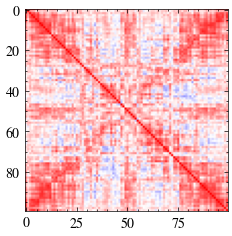

In [12]:
plt.imshow(fc_pred, vmin=-1., vmax=1., cmap='bwr')
plt.show()

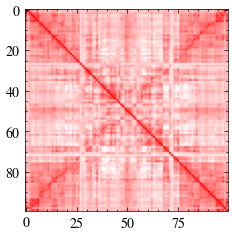

In [13]:
target_fc = dataset.fc_matrices   # (n_subjects, n_rois, n_rois)
target_fc_avg = fisher_batch_average(target_fc)  # (n_rois, n_rois)
plt.imshow(target_fc_avg.cpu(), vmin=-1.0, vmax=1.0, cmap='bwr')
plt.show()

In [14]:
pred_flat = upper_tri_vec(fc_pred, k=1)
targ_flat = upper_tri_vec(fc_target, k=1)
pred_c = pred_flat - pred_flat.mean(dim=-1, keepdim=True)
targ_c = targ_flat - targ_flat.mean(dim=-1, keepdim=True)
num = (pred_c * targ_c).sum(dim=-1)
den = torch.sqrt((pred_c ** 2).sum(dim=-1) * (targ_c ** 2).sum(dim=-1)) + 1e-8
(1.0 - num / den).mean()

tensor(0.2685)

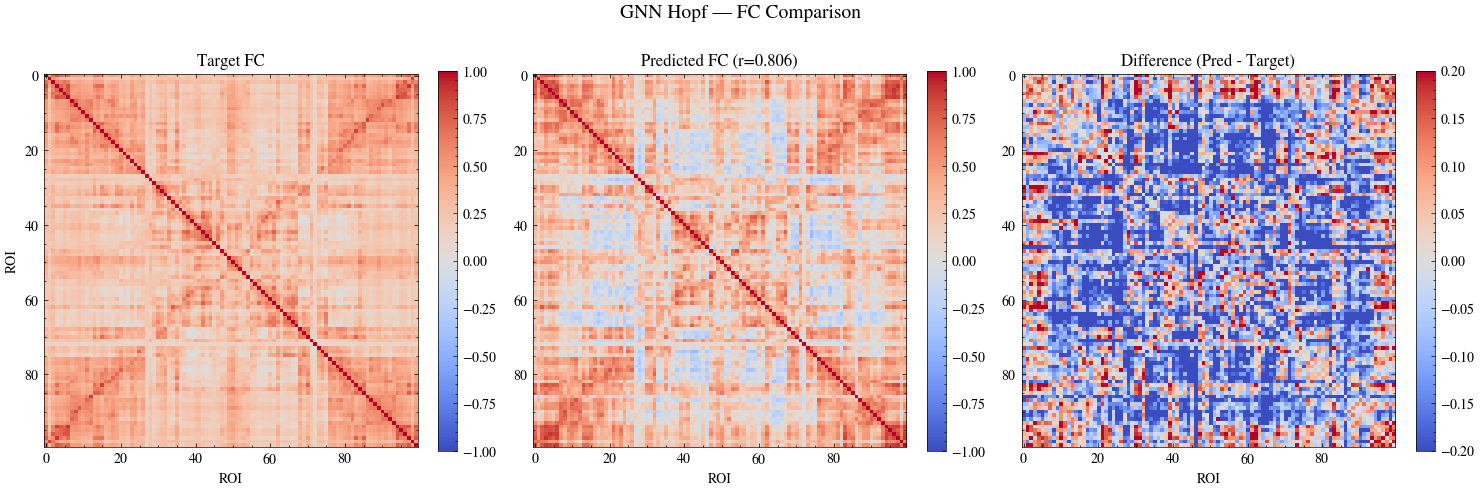

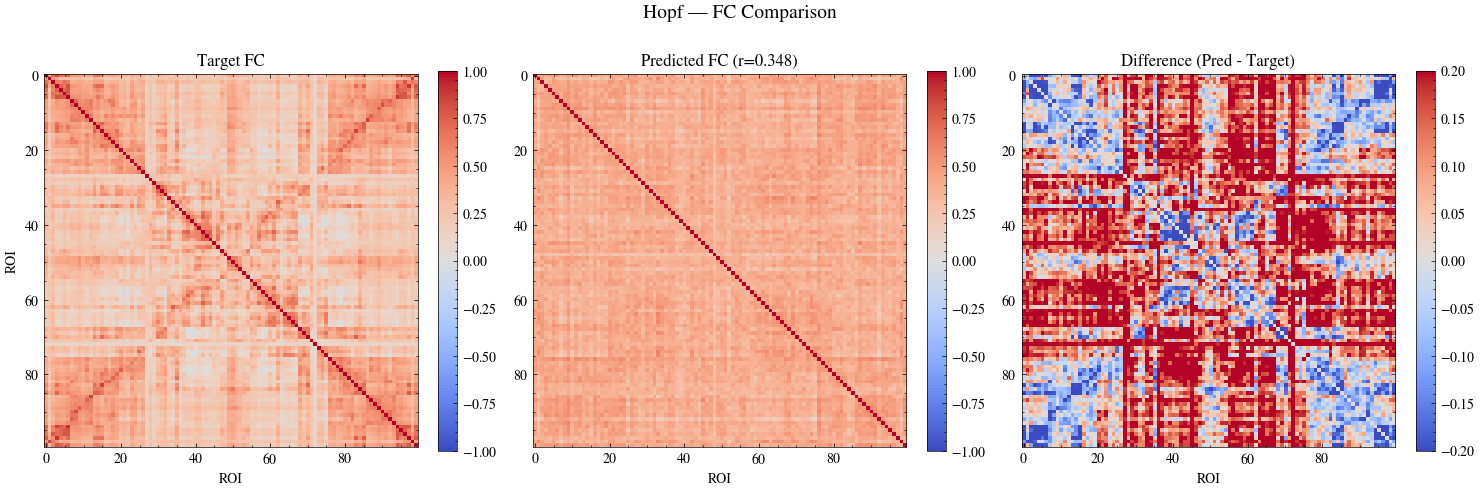

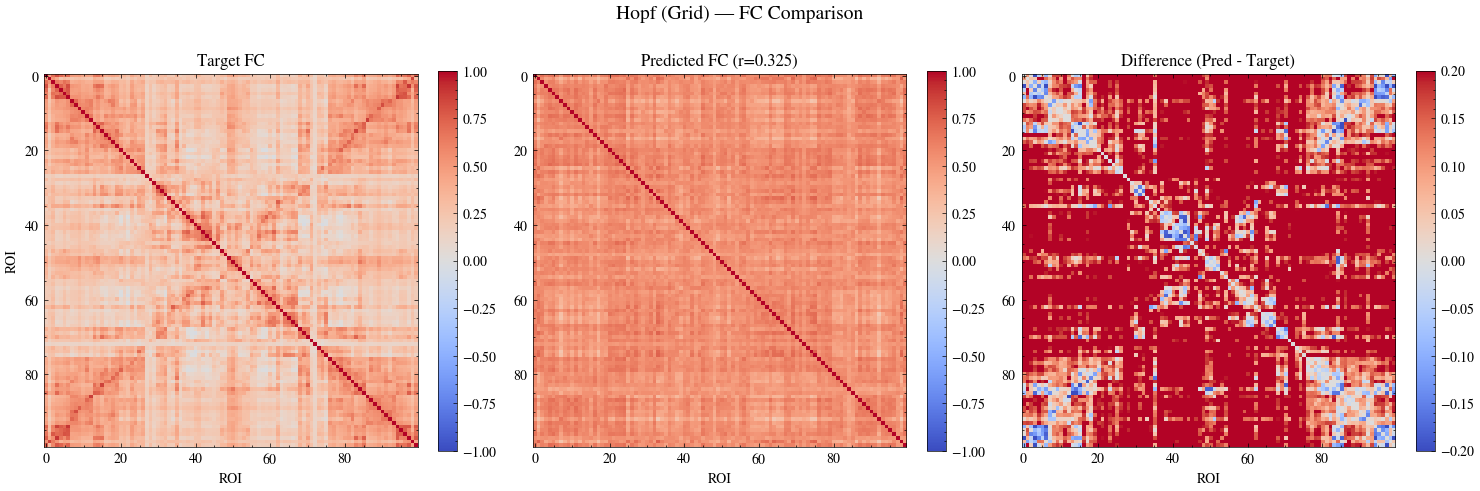

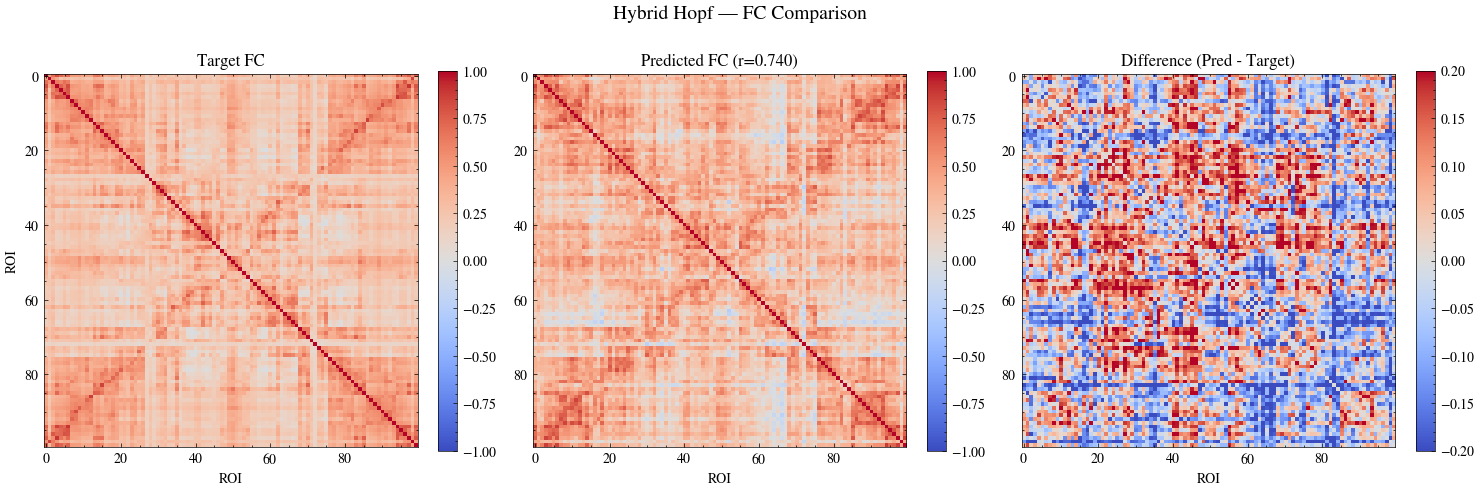

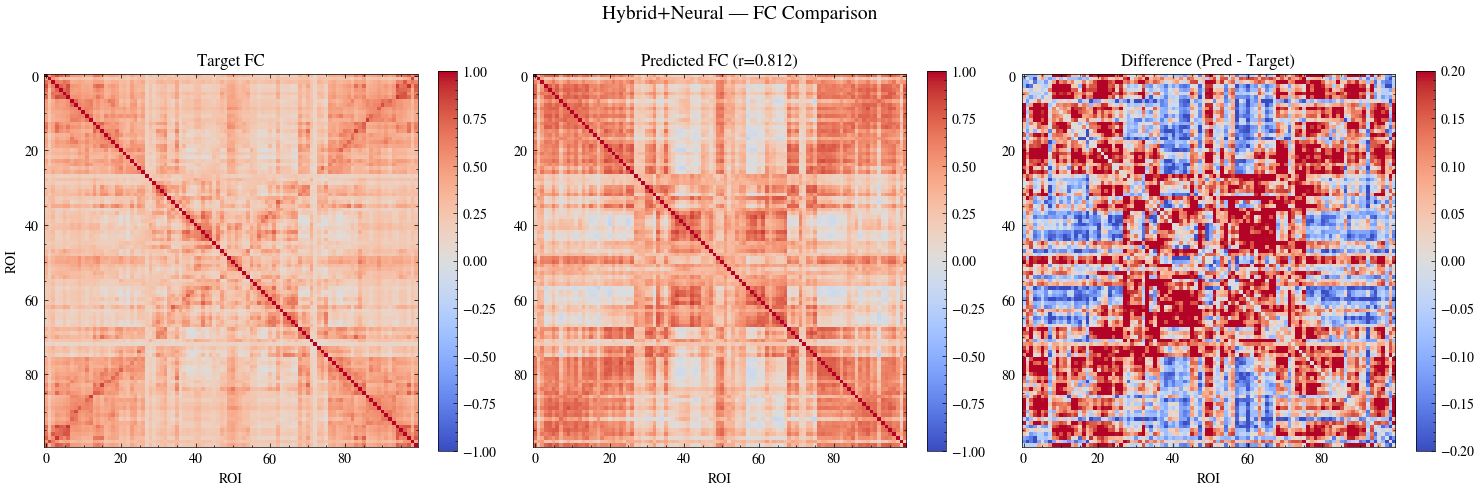

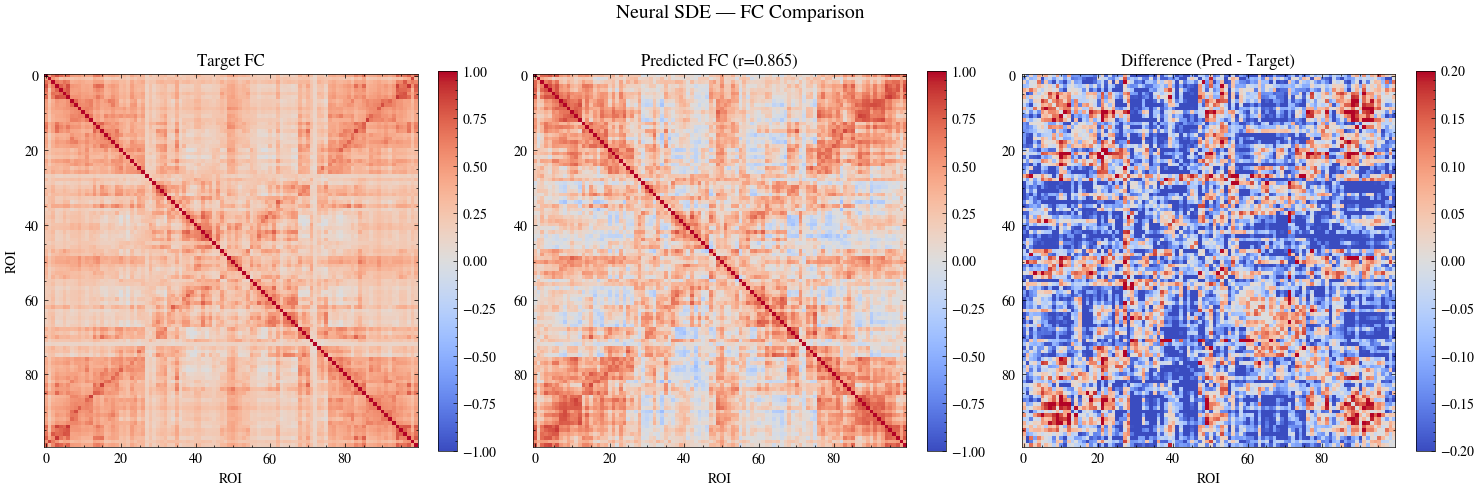

In [15]:
fc_target = reshape_for_groups(compute_static_fc(ts_target), 0)
fc_target = fisher_batch_average(fc_target)

for name, ts_pred in ts_preds.items():
    fc_pred = reshape_for_groups(compute_static_fc(ts_pred), 0)
    fc_pred = fisher_batch_average(fc_pred)

    if len(fc_target.shape) == 3:
        fc_pred = fc_pred.mean(dim=0)
        fc_target = fc_target.mean(dim=0)

    fig = plot_fc_comparison(
        fc_pred, target_fc,
        title=f"{name} — FC Comparison",
        save_path=None,   # set to a path string to save, e.g. f"paper/images/{name}_fc.pdf"
        use_pdf=False,
    )

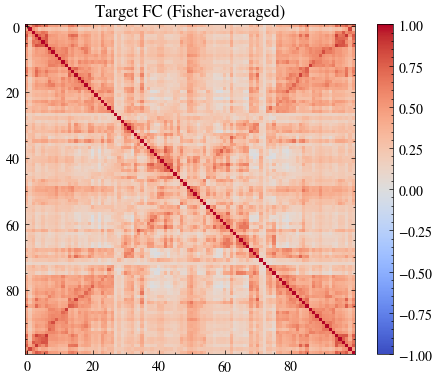

In [16]:
target_fc = dataset.fc_matrices   # (n_subjects, n_rois, n_rois)
target_fc_avg = fisher_batch_average(target_fc)  # (n_rois, n_rois)

plt.figure(figsize=(5, 4))
plt.imshow(target_fc_avg.detach().cpu().numpy(), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(fraction=0.046)
plt.title("Target FC (Fisher-averaged)")
plt.tight_layout()
plt.show()

## 4. Per-model FC Comparison

## 5. Comparison Report (all models side-by-side)

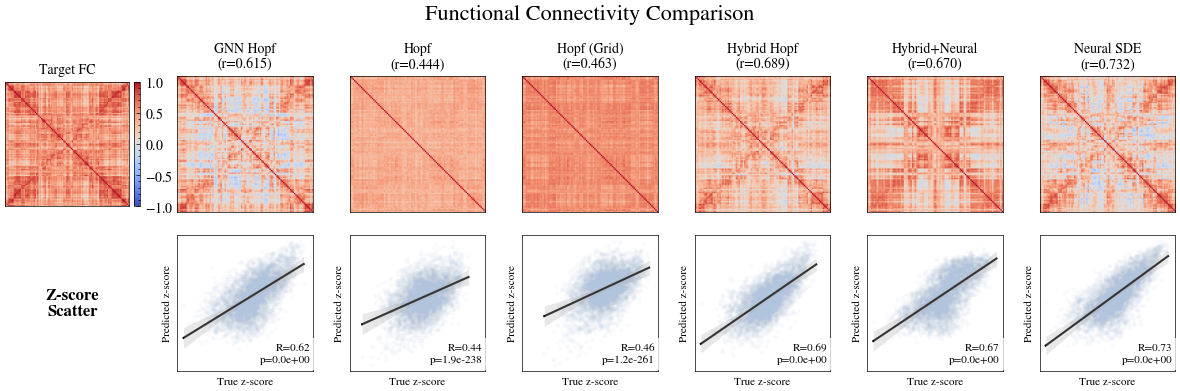

In [20]:
import numpy as np
from matplotlib.gridspec import GridSpec
from scipy.stats import linregress, t as student_t

n_models = len(models)
n_cols = n_models + 1
fig = plt.figure(figsize=(12,4))
use_zscore_scatter = True
# Using GridSpec to manage the layout
gs = GridSpec(2, n_cols, figure=fig)

# 1. Target FC (First Column, First Row)
ax_target = fig.add_subplot(gs[0, 0])

fc_target = reshape_for_groups(compute_static_fc(ts_target), 0)
fc_target = fisher_batch_average(fc_target)
target_np = fc_target.detach().cpu().numpy()
    
im = ax_target.imshow(target_np, cmap='coolwarm', vmin=-1, vmax=1)
ax_target.set_title('Target FC', fontsize=10)

# Remove ticks from first row/first col
ax_target.set_xticks([])
ax_target.set_yticks([])

# Only add colorbar to the first plot
# fraction and pad help keep the square from shrinking too much
plt.colorbar(im, ax=ax_target, fraction=0.046, pad=0.04)

all_metrics = {}

fc_target = reshape_for_groups(compute_static_fc(ts_target), 0)
fc_target = fisher_batch_average(fc_target)

# Iterate through models (Columns 1 to N)
for i, (name, ts_pred) in enumerate(ts_preds.items()):
    col_idx = i + 1
    
    # fc_pred = model.compute_fc(ts_pred)
    # fc_pred_np = fc_pred[0].detach().cpu().numpy()

    fc_pred = reshape_for_groups(compute_static_fc(ts_pred), 0)
    fc_pred = fisher_batch_average(fc_pred)
    fc_pred_np = fc_pred.detach().cpu().numpy()

    # --- Row 0: Predicted FC (imshow) ---
    ax_fc = fig.add_subplot(gs[0, col_idx])
    ax_fc.imshow(fc_pred_np, cmap='coolwarm', vmin=-1, vmax=1)
    
    # Metrics Calculation
    # (Assuming your helper functions: upper_tri_vec, fisher_batch_average exist)
    # Note: Shortened for brevity, keeping your logic
    p = fc_pred_np[np.triu_indices_from(fc_pred_np, k=1)]
    t = target_np[np.triu_indices_from(target_np, k=1)]
    fc_corr = np.corrcoef(p, t)[0, 1]
    
    metrics = {"fc_correlation": fc_corr, "fc_mse": np.mean((p - t)**2)}
    all_metrics[name] = metrics

    ax_fc.set_title(f'{name}\n(r={fc_corr:.3f})', fontsize=10)
    
    # Remove ticks and ensure square alignment
    ax_fc.set_xticks([])
    ax_fc.set_yticks([])

    # --- Row 1: FC Scatter / z-score regression ---
    ax_scatter = fig.add_subplot(gs[1, col_idx])
    if use_zscore_scatter:
        t_plot = (t - t.mean()) / (t.std(ddof=1) + 1e-12)
        p_plot = (p - p.mean()) / (p.std(ddof=1) + 1e-12)
        ax_scatter.set_xlabel('True z-score', fontsize=8)
        ax_scatter.set_ylabel('Predicted z-score', fontsize=8)
        lim_min = min(t_plot.min(), p_plot.min())
        lim_max = max(t_plot.max(), p_plot.max())
        pad = 0.05 * max(lim_max - lim_min, 1e-6)
        ax_scatter.set_xlim(lim_min - pad, lim_max + pad)
        ax_scatter.set_ylim(lim_min - pad, lim_max + pad)
    else:
        t_plot = t
        p_plot = p
        ax_scatter.set_xlabel('Target FC', fontsize=8)
        ax_scatter.set_ylabel('Predicted FC', fontsize=8)
        ax_scatter.set_xlim(-1, 1)
        ax_scatter.set_ylim(-1, 1)
    fit = linregress(t_plot, p_plot)
    x_line = np.linspace(t_plot.min(), t_plot.max(), 200)
    y_line = fit.intercept + fit.slope * x_line
    if t_plot.size >= 3:
        x_mean = t_plot.mean()
        sxx = ((t_plot - x_mean) ** 2).sum()
        if sxx > 0:
            y_hat = fit.intercept + fit.slope * t_plot
            residual_se = np.sqrt(np.sum((p_plot - y_hat) ** 2) / max(t_plot.size - 2, 1))
            line_se = residual_se * np.sqrt((1.0 / t_plot.size) + ((x_line - x_mean) ** 2) / sxx)
            t_value = student_t.ppf(0.9, df=t_plot.size - 2)
            band = t_value * line_se * 10
            ax_scatter.fill_between(x_line, y_line - band, y_line + band, color='0.7', alpha=0.3, linewidth=0, zorder=10)
    ax_scatter.scatter(t_plot, p_plot, alpha=0.04, s=5, c="lightsteelblue", zorder=2)
    ax_scatter.plot(x_line, y_line, color='black', linewidth=1.5, zorder=3)
    ax_scatter.text(
        0.98, 0.05,
        f'R={fit.rvalue:.2f}\np={fit.pvalue:.1e}',
        transform=ax_scatter.transAxes,
        ha='right', va='bottom', fontsize=8,
        bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'}
    )
    
    # Ensure the scatter plot is a square that aligns with the imshow above
    ax_scatter.set_aspect('equal') 
    
    # Remove ticks from second row
    ax_scatter.set_xticks([])
    ax_scatter.set_yticks([])
    # ax_scatter.set_title(f'{name} Scatter', fontsize=9)

# Label for the second row (First Column, Second Row)
ax_label = fig.add_subplot(gs[1, 0])
ax_label.axis('off')
ax_label.text(0.5, 0.5, 'Z-score\nScatter' if use_zscore_scatter else 'FC\nScatter', ha='center', va='center', 
                fontweight='bold', fontsize=12)

plt.suptitle('Functional Connectivity Comparison', fontsize=16, y=0.98)

# Adjust layout to prevent overlap while maintaining aspects
plt.tight_layout()
plt.savefig("paper/images/ts_young/fc_comparison2.pdf", bbox_inches='tight')

/tmp/ipykernel_3852888/691413167.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


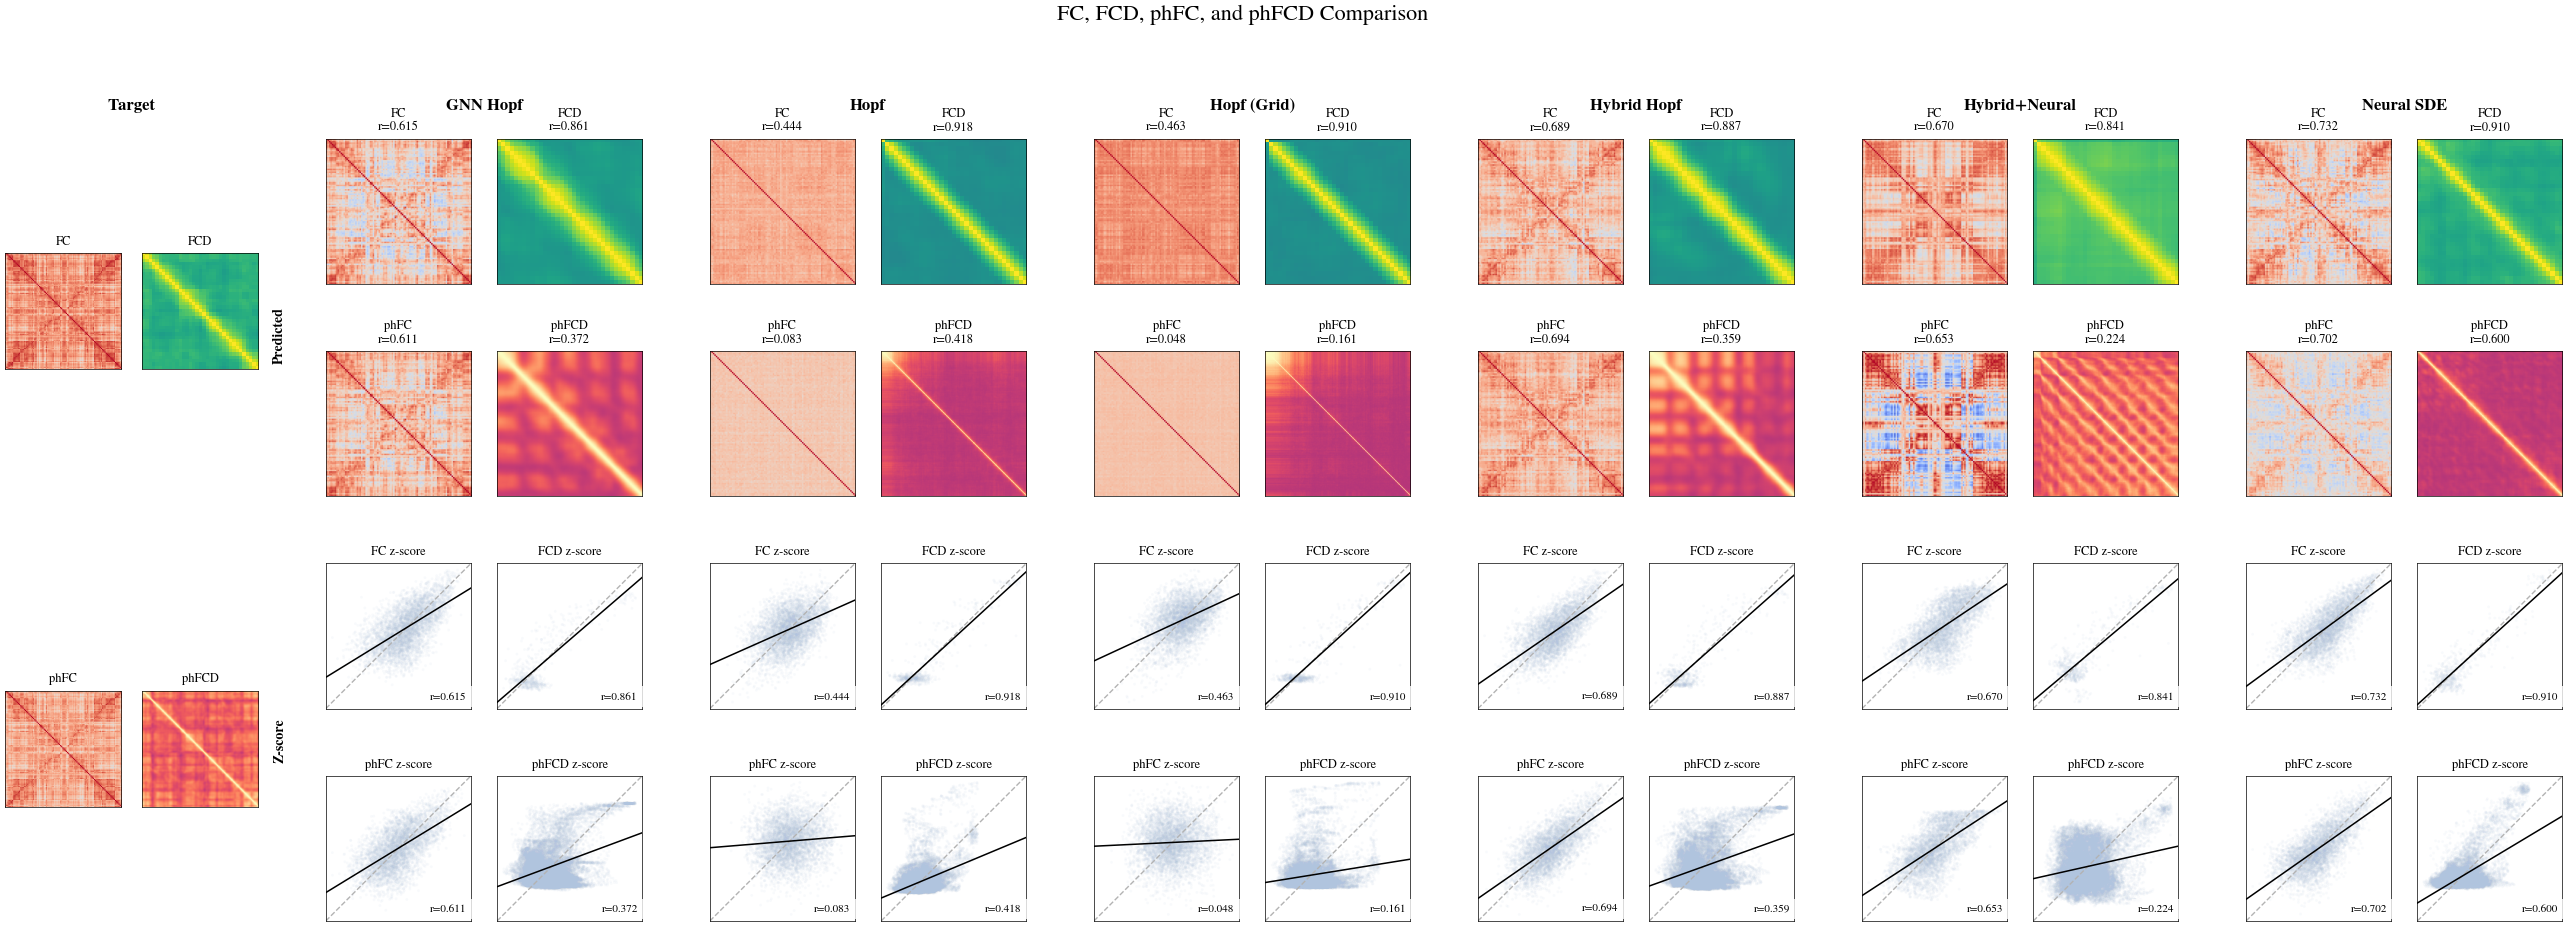

In [18]:
from src.metrics.dynamics_metrics import fcd_matrix, phfcd_matrix, phase_coherence_fc

import numpy as np
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.stats import linregress

FCD_WIN_LEN = globals().get('FCD_WIN_LEN', 30)
FCD_WIN_STEP = globals().get('FCD_WIN_STEP', 5)


def _average_fc_np(ts):
    fc = reshape_for_groups(compute_static_fc(ts), 0)
    return fisher_batch_average(fc).detach().cpu().numpy()


def _average_phfc_np(ts):
    if not torch.is_complex(ts):
        return None
    phfc = reshape_for_groups(phase_coherence_fc(ts), 0)
    return fisher_batch_average(phfc).detach().cpu().numpy()


def _average_subject_matrix_np(ts, matrix_builder):
    mats = []
    for subject_ts in ts:
        mat = matrix_builder(subject_ts)
        if mat is not None:
            mats.append(mat.detach().cpu().numpy())
    if not mats:
        return None
    return np.mean(np.stack(mats, axis=0), axis=0)


def _average_fcd_np(ts):
    return _average_subject_matrix_np(
        ts,
        lambda subject_ts: fcd_matrix(
            subject_ts.real.T if torch.is_complex(subject_ts) else subject_ts.T,
            FCD_WIN_LEN,
            FCD_WIN_STEP,
        ),
    )


def _average_phfcd_np(ts):
    if not torch.is_complex(ts):
        return None
    return _average_subject_matrix_np(
        ts,
        lambda subject_ts: phfcd_matrix(torch.angle(subject_ts).T),
    )


def _upper_tri_vec_np(matrix):
    idx = np.triu_indices_from(matrix, k=1)
    return np.asarray(matrix[idx], dtype=float)


def _matrix_corr(target_matrix, pred_matrix):
    if target_matrix is None or pred_matrix is None or target_matrix.shape != pred_matrix.shape:
        return np.nan
    target_vec = _upper_tri_vec_np(target_matrix)
    pred_vec = _upper_tri_vec_np(pred_matrix)
    if target_vec.size < 2:
        return np.nan
    return float(np.corrcoef(target_vec, pred_vec)[0, 1])


def _plot_matrix(ax, matrix, *, title, cmap, clim=None):
    if matrix is None:
        ax.axis('off')
        ax.text(0.5, 0.5, f'{title}\nunavailable', ha='center', va='center', fontsize=9)
        return

    if clim is None:
        im = ax.imshow(matrix, cmap=cmap)
    else:
        im = ax.imshow(matrix, cmap=cmap, vmin=clim[0], vmax=clim[1])

    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    return im


def _plot_zscore_scatter(ax, target_matrix, pred_matrix, *, title):
    if target_matrix is None or pred_matrix is None or target_matrix.shape != pred_matrix.shape:
        ax.axis('off')
        ax.text(0.5, 0.5, f'{title}\nz-score unavailable', ha='center', va='center', fontsize=8)
        return np.nan

    target_vec = _upper_tri_vec_np(target_matrix)
    pred_vec = _upper_tri_vec_np(pred_matrix)
    if target_vec.size < 2:
        ax.axis('off')
        ax.text(0.5, 0.5, f'{title}\ninsufficient data', ha='center', va='center', fontsize=8)
        return np.nan

    target_z = (target_vec - target_vec.mean()) / (target_vec.std(ddof=1) + 1e-12)
    pred_z = (pred_vec - pred_vec.mean()) / (pred_vec.std(ddof=1) + 1e-12)
    corr = float(np.corrcoef(target_vec, pred_vec)[0, 1])

    ax.scatter(target_z, pred_z, s=4, alpha=0.08, c='lightsteelblue', edgecolors='none')

    lim_min = float(min(target_z.min(), pred_z.min()))
    lim_max = float(max(target_z.max(), pred_z.max()))
    pad = 0.05 * max(lim_max - lim_min, 1e-6)
    lo = lim_min - pad
    hi = lim_max + pad
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.plot([lo, hi], [lo, hi], color='0.7', linewidth=1.0, linestyle='--', zorder=1)

    if np.ptp(target_z) > 1e-12:
        fit = linregress(target_z, pred_z)
        x_line = np.linspace(lo, hi, 200)
        ax.plot(x_line, fit.intercept + fit.slope * x_line, color='black', linewidth=1.1, zorder=3)

    ax.text(
        0.97,
        0.05,
        f'r={corr:.3f}',
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=8,
        bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'},
    )
    ax.set_title(f'{title} z-score', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', 'box')
    return corr


matrix_specs = [
    ('fc', 'FC', 'coolwarm', (-1.0, 1.0)),
    ('fcd', 'FCD', 'viridis', (-1.0, 1.0)),
    ('phfc', 'phFC', 'coolwarm', (-1.0, 1.0)),
    ('phfcd', 'phFCD', 'magma', (-1.0, 1.0)),
]

target_matrices = {
    'fc': _average_fc_np(ts_target),
    'fcd': _average_fcd_np(ts_target),
    'phfc': _average_phfc_np(ts_target),
    'phfcd': _average_phfcd_np(ts_target),
}

model_matrices = {}
all_metrics = {}
for name, ts_pred in ts_preds.items():
    pred_matrices = {
        'fc': _average_fc_np(ts_pred),
        'fcd': _average_fcd_np(ts_pred),
        'phfc': _average_phfc_np(ts_pred),
        'phfcd': _average_phfcd_np(ts_pred),
    }
    model_matrices[name] = pred_matrices
    all_metrics[name] = {
        f'{key}_correlation': _matrix_corr(target_matrices[key], pred_matrices[key])
        for key, _, _, _ in matrix_specs
    }

n_models = len(model_matrices)
fig = plt.figure(figsize=(4.2 + 4.8 * n_models, 10.5))
outer = GridSpec(
    1,
    n_models + 1,
    figure=fig,
    width_ratios=[1.0] + [1.25] * n_models,
    wspace=0.22,
)

target_grid = GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0, 0], hspace=0.18, wspace=0.18)
for idx, (key, label, cmap, clim) in enumerate(matrix_specs):
    ax = fig.add_subplot(target_grid[idx // 2, idx % 2])
    _plot_matrix(ax, target_matrices[key], title=label, cmap=cmap, clim=clim)

target_bbox = outer[0, 0].get_position(fig)
fig.text(
    0.5 * (target_bbox.x0 + target_bbox.x1),
    target_bbox.y1 + 0.012,
    'Target',
    ha='center',
    va='bottom',
    fontsize=12,
    fontweight='bold',
)

for model_idx, (name, pred_matrices) in enumerate(model_matrices.items(), start=1):
    panel = GridSpecFromSubplotSpec(4, 2, subplot_spec=outer[0, model_idx], hspace=0.24, wspace=0.18)

    panel_bbox = outer[0, model_idx].get_position(fig)
    fig.text(
        0.5 * (panel_bbox.x0 + panel_bbox.x1),
        panel_bbox.y1 + 0.012,
        name,
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
    )

    for idx, (key, label, cmap, clim) in enumerate(matrix_specs):
        corr = all_metrics[name][f'{key}_correlation']
        title = label if not np.isfinite(corr) else f'{label}\nr={corr:.3f}'
        ax = fig.add_subplot(panel[idx // 2, idx % 2])
        _plot_matrix(ax, pred_matrices[key], title=title, cmap=cmap, clim=clim)

    for idx, (key, label, _, _) in enumerate(matrix_specs):
        ax = fig.add_subplot(panel[2 + idx // 2, idx % 2])
        _plot_zscore_scatter(ax, target_matrices[key], pred_matrices[key], title=label)

if n_models:
    first_model_bbox = outer[0, 1].get_position(fig)
    fig.text(
        first_model_bbox.x0 - 0.012,
        target_bbox.y0 + 0.74 * (target_bbox.y1 - target_bbox.y0),
        'Predicted',
        rotation=90,
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
    )
    fig.text(
        first_model_bbox.x0 - 0.012,
        target_bbox.y0 + 0.24 * (target_bbox.y1 - target_bbox.y0),
        'Z-score',
        rotation=90,
        ha='right',
        va='center',
        fontsize=10,
        fontweight='bold',
    )

plt.suptitle('FC, FCD, phFC, and phFCD Comparison', fontsize=16, y=0.995)
plt.tight_layout()
save_path = Path(f'paper/images/{DATASET_TYPE}/fc_fcd_phfc_phfcd_comparison.pdf')
save_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(save_path, bbox_inches='tight')
plt.show()


## 6. Tribev2-style Brain Timesteps

This section builds a self-contained surface montage inspired by the Tribev2 paper using `nilearn` only. The first run may download the Schaefer atlas and `fsaverage5` surfaces into the Nilearn cache.


In [ ]:
aaaaa

NameError: name 'aaaaa' is not defined

: 

In [ ]:
from functools import lru_cache

import nibabel as nib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from nilearn import datasets, plotting, surface

TRIBE_LIKE_CMAP = LinearSegmentedColormap.from_list(
    "tribe_like_fire",
    ["#fff7bc", "#fee391", "#fec44f", "#fe9929", "#ec7014", "#cc4c02", "#8c2d04"],
)


def _to_numpy(array_like):
    if torch.is_tensor(array_like):
        return array_like.detach().cpu().numpy()
    return np.asarray(array_like)


def _prepare_brain_timeseries(array_like, n_rois, subject_index=0, complex_mode="real"):
    arr = _to_numpy(array_like)

    if arr.ndim == 3:
        arr = arr.mean(axis=0) if subject_index is None else arr[int(subject_index)]
    elif arr.ndim != 2:
        raise ValueError(f"Expected a 2-D or 3-D array, got shape {arr.shape}.")

    if np.iscomplexobj(arr):
        if complex_mode == "real":
            arr = arr.real
        elif complex_mode == "imag":
            arr = arr.imag
        elif complex_mode == "abs":
            arr = np.abs(arr)
        else:
            raise ValueError("complex_mode must be one of: 'real', 'imag', 'abs'.")

    arr = np.asarray(arr, dtype=float)
    if arr.shape[0] != n_rois and arr.shape[1] == n_rois:
        arr = arr.T

    if arr.shape[0] != n_rois:
        raise ValueError(
            f"Could not align timeseries with n_rois={n_rois}. Final shape was {arr.shape}."
        )

    return arr


def _positive_zscore_activity(series):
    centered = series - np.nanmean(series)
    scale = np.nanstd(centered)
    z = centered / (scale + 1e-6)
    return np.clip(z, 0.0, None)


@lru_cache(maxsize=8)
def _load_surface_projection(n_rois, mesh="fsaverage5"):
    n_rois = int(n_rois)
    if n_rois % 100 != 0 or not (100 <= n_rois <= 1000):
        raise ValueError(
            "Schaefer surface plotting expects n_rois in {100, 200, ..., 1000}."
        )

    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=7,
        resolution_mm=2,
    )
    labels_img = nib.load(atlas["maps"])
    fsaverage = datasets.fetch_surf_fsaverage(mesh=mesh)

    def sample_labels(mesh_path):
        labels = surface.vol_to_surf(
            labels_img,
            mesh_path,
            interpolation="nearest_most_frequent",
        )
        return np.rint(labels).astype(int)

    return {
        "fsaverage": fsaverage,
        "labels_left": sample_labels(fsaverage.pial_left),
        "labels_right": sample_labels(fsaverage.pial_right),
    }


def _roi_to_surface(roi_values, label_texture):
    surf_values = np.zeros(label_texture.shape, dtype=float)
    mask = label_texture > 0
    surf_values[mask] = roi_values[label_texture[mask] - 1]
    return surf_values

In [ ]:
BRAIN_TIMESTEP_SUBJECT = 0  # set to None to average across the current batch
BRAIN_TIMESTEP_COLUMNS = min(10, N_TIMEPOINTS)
BRAIN_TIMESTEP_INDEX = np.unique(
    np.linspace(0, N_TIMEPOINTS - 1, num=BRAIN_TIMESTEP_COLUMNS, dtype=int)
).tolist()

brain_rows = {"Real": ts_target}
brain_rows.update(ts_preds)

time_labels = [f"t={idx * dataset.dt:.2f}s" for idx in BRAIN_TIMESTEP_INDEX]

[fetch_atlas_schaefer_2018] Dataset found in /home/hpc/dsaa/dsaa110h/nilearn_data/schaefer_2018

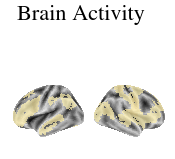

In [ ]:
threshold_percentile=20.0
scale_percentile=99.5
mesh="fsaverage5"
n_rois = dataset.n_rois
subject_index = 1
complex_mode = "real"
time_indices = np.array([0])


prepared = {
    name: _positive_zscore_activity(
        _prepare_brain_timeseries(
            series,
            n_rois=n_rois,
            subject_index=subject_index,
            complex_mode=complex_mode,
        )
    )
    for name, series in brain_rows.items()
}

n_rows = 1  #len(prepared)
n_cols = len(time_indices)  #len(time_indices)

fig = plt.figure(figsize=(1.85 * n_cols, 1.7 * n_rows + 0.7), facecolor="white")
outer = GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    left=0.09,
    right=0.985,
    top=0.90,
    bottom=0.14,
    wspace=0.03,
    hspace=0.32,
)

projection = _load_surface_projection(n_rois=n_rois, mesh=mesh)

t_idx = time_indices[0]
row, col = 0, 0
series = prepared["Real"]
roi_values = series[:, t_idx]
inner = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[row, col], wspace=-0.05)

all_vals = np.concatenate([series[:, time_indices].ravel() for series in prepared.values()])
positive_vals = all_vals[all_vals > 0]
vmax = np.percentile(positive_vals, scale_percentile) if positive_vals.size else 1.0
threshold = np.percentile(positive_vals, threshold_percentile) if positive_vals.size else 0.0
vmax = max(float(vmax), 1e-3)

fsaverage = projection["fsaverage"]
hemis = [
    ("left", fsaverage.infl_left, fsaverage.sulc_left, projection["labels_left"]),
    ("right", fsaverage.infl_right, fsaverage.sulc_right, projection["labels_right"]),
]

for hemi_idx, (hemi, mesh_path, bg_path, label_texture) in enumerate(hemis):
    surf_values = _roi_to_surface(roi_values, label_texture)
    ax = fig.add_subplot(inner[0, hemi_idx], projection="3d")
    plotting.plot_surf_stat_map(
        mesh_path,
        surf_values,
        hemi=hemi,
        view="lateral",
        bg_map=bg_path,
        bg_on_data=True,
        threshold=threshold,
        cmap=TRIBE_LIKE_CMAP,
        colorbar=False,
        symmetric_cbar=False,
        vmin=0.0,
        vmax=vmax,
        figure=fig,
        axes=ax,
    )
    ax.set_axis_off()
fig.suptitle("Brain Activity", fontsize=16, y=0.965)
plt.show()

In [ ]:
def plot_brain_timestep_rows(
    series_by_name,
    time_indices,
    *,
    n_rois,
    subject_index=0,
    complex_mode="real",
    mesh="fsaverage5",
    scale_percentile=99.0,
    threshold_percentile=70.0,
    title="Tribev2-style brain timestep montage",
    time_labels=None,
    column_labels=None,
):
    projection = _load_surface_projection(n_rois=n_rois, mesh=mesh)
    prepared = {
        name: _positive_zscore_activity(
            _prepare_brain_timeseries(
                series,
                n_rois=n_rois,
                subject_index=subject_index,
                complex_mode=complex_mode,
            )
        )
        for name, series in series_by_name.items()
    }

    time_indices = list(dict.fromkeys(int(t) for t in time_indices))
    if not time_indices:
        raise ValueError("time_indices must contain at least one timestep.")

    all_vals = np.concatenate([series[:, time_indices].ravel() for series in prepared.values()])
    positive_vals = all_vals[all_vals > 0]
    vmax = np.percentile(positive_vals, scale_percentile) if positive_vals.size else 1.0
    threshold = np.percentile(positive_vals, threshold_percentile) if positive_vals.size else 0.0
    vmax = max(float(vmax), 1e-3)

    n_rows = len(prepared)
    n_cols = len(time_indices)
    fig = plt.figure(figsize=(1.85 * n_cols, 1.0 * n_rows + 0.7), facecolor="white")
    outer = GridSpec(
        n_rows,
        n_cols,
        figure=fig,
        left=0.09,
        right=0.985,
        top=0.90,
        bottom=0.14,
        wspace=0.03,
        hspace=0.32,
    )

    fsaverage = projection["fsaverage"]
    hemis = [
        ("left", fsaverage.infl_left, fsaverage.sulc_left, projection["labels_left"]),
        ("right", fsaverage.infl_right, fsaverage.sulc_right, projection["labels_right"]),
    ]

    for row, (name, series) in enumerate(prepared.items()):
        row_bbox = outer[row, 0].get_position(fig)
        fig.text(
            row_bbox.x0 - 0.012,
            0.5 * (row_bbox.y0 + row_bbox.y1),
            name,
            ha="right",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

        for col, t_idx in enumerate(time_indices):
            roi_values = series[:, t_idx]
            inner = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[row, col], wspace=-0.05)

            for hemi_idx, (hemi, mesh_path, bg_path, label_texture) in enumerate(hemis):
                surf_values = _roi_to_surface(roi_values, label_texture)
                ax = fig.add_subplot(inner[0, hemi_idx], projection="3d")
                plotting.plot_surf_stat_map(
                    mesh_path,
                    surf_values,
                    hemi=hemi,
                    view="lateral",
                    bg_map=bg_path,
                    bg_on_data=True,
                    threshold=threshold,
                    cmap=TRIBE_LIKE_CMAP,
                    colorbar=False,
                    symmetric_cbar=False,
                    vmin=0.0,
                    vmax=vmax,
                    figure=fig,
                    axes=ax,
                )
                ax.set_axis_off()

    if time_labels is None:
        time_labels = [f"t={t * dataset.dt:.2f}s" for t in time_indices]

    for col, label in enumerate(time_labels):
        bbox = outer[n_rows - 1, col].get_position(fig)
        fig.text(
            0.5 * (bbox.x0 + bbox.x1),
            bbox.y0 - 0.030,
            label,
            ha="center",
            va="top",
            fontsize=9,
        )

    if column_labels:
        for col, label in column_labels.items():
            if 0 <= col < n_cols:
                bbox = outer[n_rows - 1, col].get_position(fig)
                fig.text(
                    0.5 * (bbox.x0 + bbox.x1),
                    bbox.y0 - 0.070,
                    label,
                    ha="center",
                    va="top",
                    fontsize=10,
                    fontweight="bold",
                )

    fig.suptitle(title, fontsize=16, y=0.965)
    return fig, prepared


: 

In [ ]:
BRAIN_TIMESTEP_SUBJECT = 0  # set to None to average across the current batch
BRAIN_TIMESTEP_COLUMNS = min(5, N_TIMEPOINTS)
BRAIN_TIMEPOINTS = min(30, N_TIMEPOINTS)
BRAIN_TIMESTEP_INDEX = np.unique(
    np.linspace(0, BRAIN_TIMEPOINTS - 1, num=BRAIN_TIMESTEP_COLUMNS, dtype=int)
).tolist()

brain_rows = {"Real": ts_target}
brain_rows.update(ts_preds)
brain_rows = {k: brain_rows[k] for k in ["Real", "Hybrid Hopf", "Hopf (Grid)"]}
# brain_rows = {k: v for k, v in brain_rows.items() if k in ["Real", "Hybrid Hopf", "Hopf (Grid)"]}

time_labels = [f"t={idx * dataset.dt:.2f}s" for idx in BRAIN_TIMESTEP_INDEX]

fig, prepared_brain_rows = plot_brain_timestep_rows(
    brain_rows,
    time_indices=BRAIN_TIMESTEP_INDEX,
    n_rois=dataset.n_rois,
    subject_index=BRAIN_TIMESTEP_SUBJECT,
    complex_mode="real",
    title="Brain simulation comparison",
    time_labels=time_labels,
    # column_labels={1: "Faces", 4: "Places", 6: "Body parts"},
)
plt.savefig("paper/images/ts_young/brain_timestep_montage.pdf", bbox_inches='tight')
plt.show()


## 7. Metrics Over Epochs

Loaded 5 model(s): ['GNN Hopf', 'Hopf', 'Hybrid Hopf', 'Hybrid+Neural', 'Neural SDE']


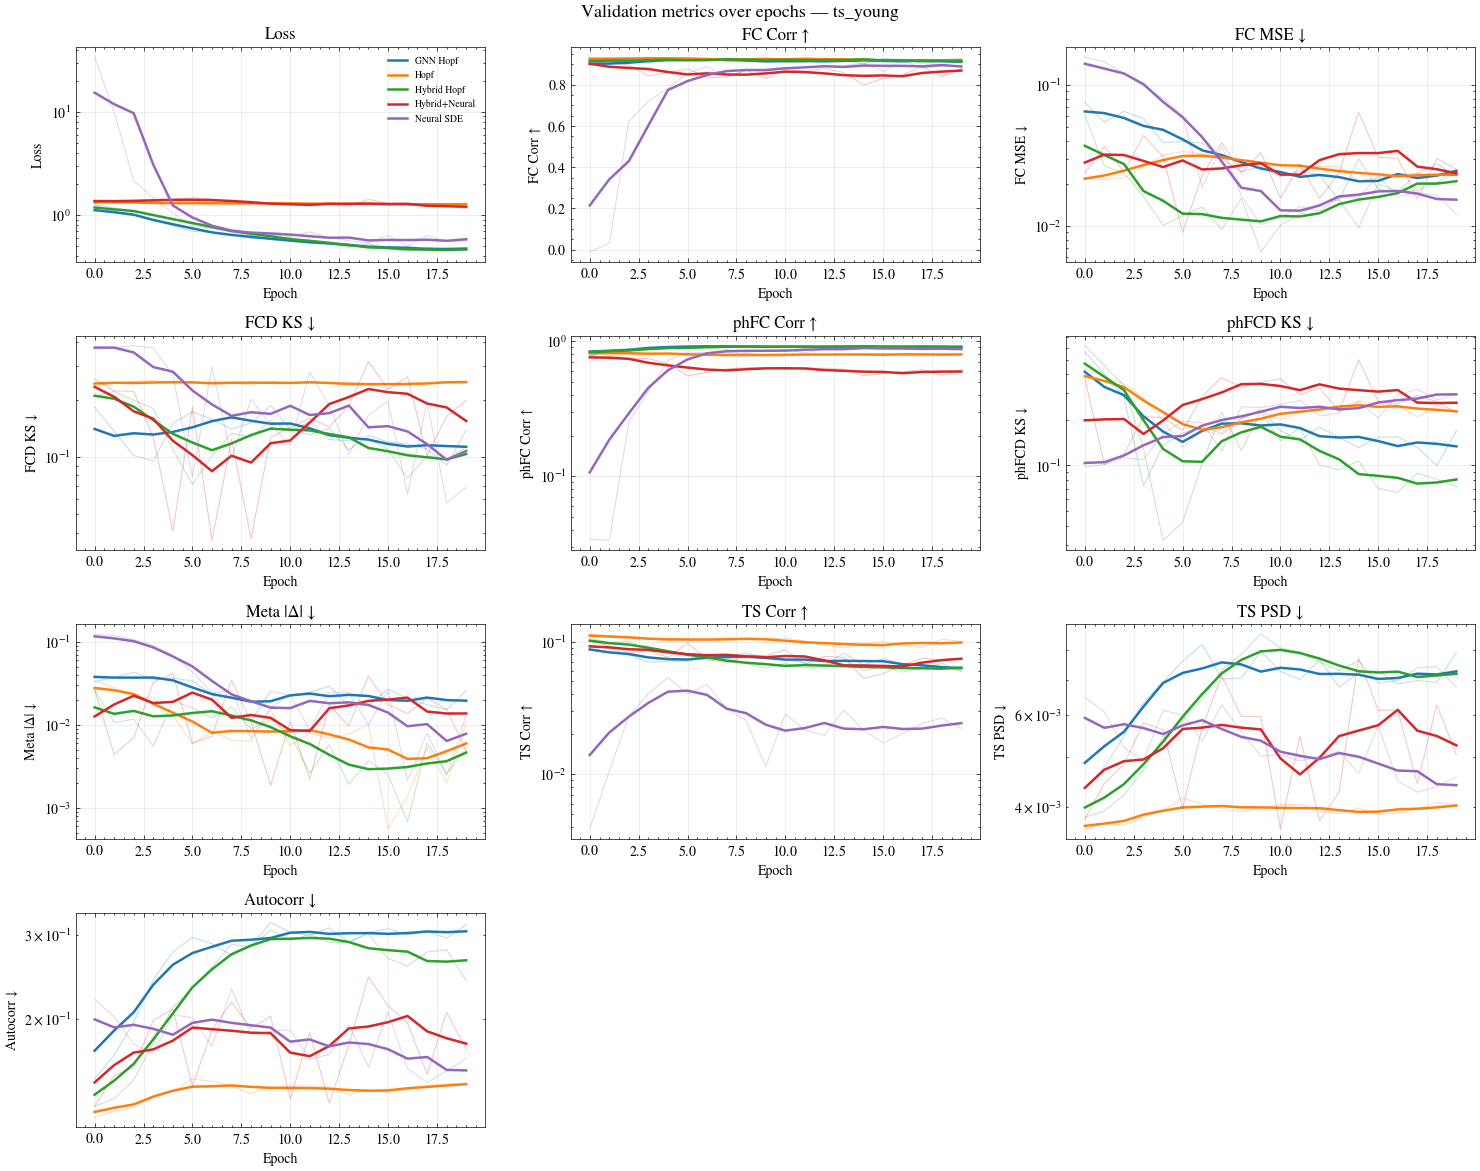

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
METRICS_DIR   = "results/metrics"   # directory with per-model metric JSON files
SMOOTH_WINDOW = 5                   # moving-average window (1 = no smoothing)
FIGSIZE_GRID  = (15, 12)            # (width, height) of the all-metrics grid figure
FIGSIZE_SPLIT = (20, 10)            # (width, height) of the loss | 3×3 split figure

# ── Imports ───────────────────────────────────────────────────────────────────
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
from src.metrics.metrics_store import MetricsStore
from examples.postprocess import _short_model_label, _EPOCH_METRICS, _smooth

# ── Load model stores ─────────────────────────────────────────────────────────
def _load_stores(dataset_type, metrics_dir):
    from pathlib import Path
    root = Path(metrics_dir)
    stores = {}
    if not root.exists():
        print(f"Metrics directory not found: {root}")
        return stores
    for sub in sorted(root.iterdir()):
        if not sub.is_dir() or dataset_type not in sub.name:
            continue
        jsons = sorted(sub.glob("*.json"))
        if not jsons:
            continue
        try:
            store = MetricsStore.load(str(jsons[-1]))
        except Exception as e:
            print(f"  Warning: {jsons[-1].name}: {e}")
            continue
        stores[_short_model_label(sub.name)] = store
    return stores

model_stores = _load_stores(DATASET_TYPE, METRICS_DIR)
colors = plt.cm.tab10.colors
print(f"Loaded {len(model_stores)} model(s): {list(model_stores)}")

# ── Figure 1: all-metrics grid ────────────────────────────────────────────────
n_cols = 3
n_rows = math.ceil(len(_EPOCH_METRICS) / n_cols)
fig1, axes = plt.subplots(n_rows, n_cols, figsize=FIGSIZE_GRID)
axes_flat = axes.flatten()

for ax_idx, (mkey, mlabel) in enumerate(_EPOCH_METRICS):
    ax = axes_flat[ax_idx]
    has_data, all_pos = False, True
    for ci, (label, store) in enumerate(model_stores.items()):
        val_vals = store.get_metric_history(mkey, "val")
        if not val_vals:
            continue
        epochs = [e["epoch"] for e in store.val_metrics if mkey in e]
        clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
        if not clean:
            continue
        ep_arr, v_arr = zip(*clean)
        color = colors[ci % len(colors)]
        ax.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
        ax.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), label=label, color=color, linewidth=1.8)
        has_data = True
        if any(v <= 0 for v in v_arr):
            all_pos = False
    ax.set_xlabel("Epoch")
    ax.set_ylabel(mlabel)
    ax.set_title(mlabel)
    ax.grid(True, alpha=0.3)
    if ax_idx == 0:
        ax.legend(fontsize=7)
    if has_data and all_pos:
        ax.set_yscale("log")

for ax_idx in range(len(_EPOCH_METRICS), len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

plt.suptitle(f"Validation metrics over epochs — {DATASET_TYPE}", fontsize=13)
plt.tight_layout()
plt.savefig(f"paper/images/{DATASET_TYPE}/metrics_over_epochs.pdf", bbox_inches="tight", dpi=150)
plt.show()



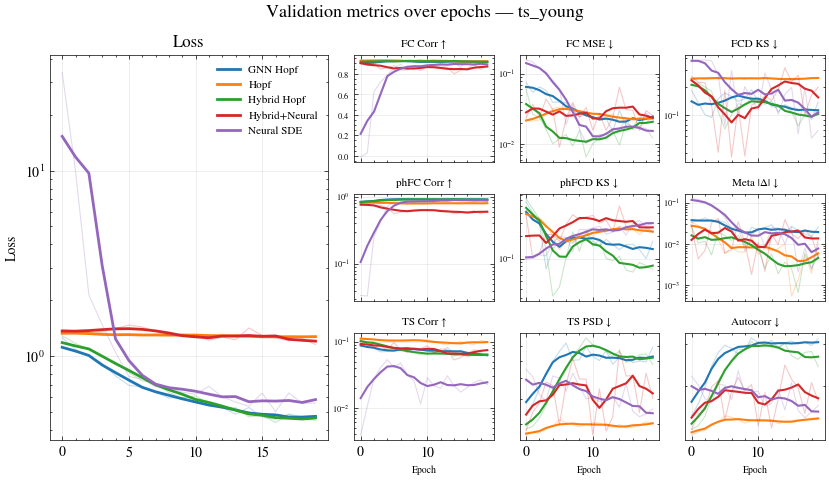

In [ ]:
import matplotlib.ticker as mticker

FIGSIZE_SPLIT = (10, 5)            # (width, height) of the loss | 3×3 split figure

other_metrics = _EPOCH_METRICS[1:10]
fig2 = plt.figure(figsize=FIGSIZE_SPLIT)
gs = mgridspec.GridSpec(3, 4, figure=fig2, width_ratios=[2, 1, 1, 1], hspace=0.3, wspace=0.15)

ax_loss = fig2.add_subplot(gs[:, 0])
has_data_loss, all_pos_loss = False, True
for ci, (label, store) in enumerate(model_stores.items()):
    val_vals = store.get_metric_history("loss", "val")
    if not val_vals:
        continue
    epochs = [e["epoch"] for e in store.val_metrics if "loss" in e]
    clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
    if not clean:
        continue
    ep_arr, v_arr = zip(*clean)
    color = colors[ci % len(colors)]
    ax_loss.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
    ax_loss.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), label=label, color=color, linewidth=2.0)
    ax_loss.set_xlabel("Epoch", fontsize=7)
    has_data_loss = True
    if any(v <= 0 for v in v_arr):
        all_pos_loss = False


ax_loss.set_ylabel("Loss")
ax_loss.set_title("Loss", fontsize=12)
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(fontsize=8)
# if has_data_loss and all_pos_loss:
ax_loss.set_yscale("log")

for idx, (mkey, mlabel) in enumerate(other_metrics):
    row, col = idx // 3, 1 + (idx % 3)
    ax = fig2.add_subplot(gs[row, col])
    has_data, all_pos = False, True
    for ci, (label, store) in enumerate(model_stores.items()):
        val_vals = store.get_metric_history(mkey, "val")
        # if not val_vals:
        #    continue
        epochs = [e["epoch"] for e in store.val_metrics if mkey in e]
        clean = [(ep, v) for ep, v in zip(epochs, val_vals) if v is not None and not math.isnan(v)]
        # if not clean:
        #   continue
        ep_arr, v_arr = zip(*clean)
        color = colors[ci % len(colors)]
        ax.plot(ep_arr, v_arr, color=color, linewidth=0.8, alpha=0.25)
        ax.plot(ep_arr, _smooth(list(v_arr), SMOOTH_WINDOW), color=color, linewidth=1.5)
        has_data = True
        if any(v <= 0 for v in v_arr):
            all_pos = False
    if row==2:
        ax.set_xlabel("Epoch", fontsize=7)
    else:
       ax.set_xticklabels([])
    # ax.set_ylabel(mlabel, fontsize=7)
    ax.set_title(mlabel, fontsize=8)
    ax.grid(True, alpha=0.3)
    if has_data and all_pos:
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
        ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())  # hide minor tick labels
    ax.tick_params(axis='y', which='major', labelsize=6)
    ax.tick_params(axis='x', which='major', labelsize=6)

plt.suptitle(f"Validation metrics over epochs — {DATASET_TYPE}", fontsize=13)
plt.savefig(f"paper/images/{DATASET_TYPE}/metrics_over_epochs_split.pdf", bbox_inches="tight", dpi=150)
plt.show()